In [1]:
import json, math, statistics
from pathlib import Path
import plotly.io as pio
import os
pio.renderers.default = "browser"

# --------- 1) Robust JSON -> list[dict] normalizer (edit here if needed) ---------
def _is_record_list(x):
    return isinstance(x, list) and (len(x) == 0 or isinstance(x[0], dict))

def extract_records(obj):
    """Return a list of dict records from a variety of common result JSON schemas.
    
    Supported patterns (common in benchmark dumps):
      - list[dict]
      - {'results': list[dict]} or {'episodes': list[dict]} or {'data': list[dict]}
      - {'runs': {'methodA': list[dict], ...}}  -> flattened with method key
      - dict-of-dicts keyed by episode_id -> converted to records
    """
    # Case 1: already a list of records
    if _is_record_list(obj):
        return obj

    # Case 2: wrapper keys
    if isinstance(obj, dict):
        for k in ("results", "episodes", "data", "records"):
            if k in obj and _is_record_list(obj[k]):
                return obj[k]

        # Case 3: dict-of-dicts keyed by episode_id
        # e.g., {"ep_0001": {..}, "ep_0002": {..}}
        if all(isinstance(v, dict) for v in obj.values()):
            recs = []
            for key, val in obj.items():
                r = dict(val)
                # keep the key as an identifier if not present
                r.setdefault("episode_id", key)
                recs.append(r)
            return recs

        # Case 4: nested 'runs' or 'methods'
        for k in ("runs", "methods", "agents"):
            if k in obj and isinstance(obj[k], dict):
                recs = []
                for method_name, payload in obj[k].items():
                    subrecs = extract_records(payload)
                    for r in subrecs:
                        rr = dict(r)
                        rr.setdefault("method", method_name)
                        recs.append(rr)
                if recs:
                    return recs

    raise ValueError("Unrecognized JSON schema. Please edit extract_records() to match your file format.")


def load_records(path: str, method_name: str):
    obj = json.loads(Path(path).read_text(encoding="utf-8"))
    recs = extract_records(obj)
    # attach method name if missing
    out = []
    for r in recs:
        rr = dict(r)
        rr.setdefault("method", method_name)
        out.append(rr)
    return out


def try_float(x):
    """Convert x to float if possible, else return None."""
    if x is None:
        return None
    if isinstance(x, (int, float)):
        if isinstance(x, bool):
            return None
        return float(x)
    if isinstance(x, str):
        s = x.strip()
        if s == "":
            return None
        try:
            return float(s)
        except ValueError:
            return None
    return None


def numeric_keys(records):
    """Infer candidate numeric metric keys from records."""
    keys = set()
    for r in records:
        for k, v in r.items():
            if k in ("method",):
                continue
            fv = try_float(v)
            if fv is not None and not math.isnan(fv) and not math.isinf(fv):
                keys.add(k)
    return sorted(keys)


def summarize_by_method(records, metric_keys):
    """Compute mean, std, count for each metric per method."""
    by_m = {}
    for r in records:
        m = r.get("method", "unknown")
        by_m.setdefault(m, []).append(r)

    summary = {}  # method -> metric -> stats
    for m, rs in by_m.items():
        summary[m] = {}
        for k in metric_keys:
            vals = []
            for r in rs:
                fv = try_float(r.get(k))
                if fv is None or math.isnan(fv) or math.isinf(fv):
                    continue
                vals.append(fv)
            if len(vals) == 0:
                continue
            mu = statistics.fmean(vals)
            sd = statistics.pstdev(vals) if len(vals) > 1 else 0.0
            summary[m][k] = {"mean": mu, "std": sd, "n": len(vals)}
    return summary


In [2]:
# --------- 2) Load & merge all results in ONE block ---------
base = os.path.expanduser("~/lighthouse/home/junzhe/Projects/SG-VLN")
poliformer_path = os.path.join(base, "dump2/benchmark_poliformer_jan28/result.json")
uninavid_path   = os.path.join(base, "dump2/benchmark_uninavid_jan28/result.json")

records = []
records += load_records(poliformer_path, method_name="poliformer")
records += load_records(uninavid_path,   method_name="uninavid")
print("Loaded records:", len(records))

# Infer numeric metric keys (you can override manually if you want)
metric_keys = numeric_keys(records)
summary = summarize_by_method(records, metric_keys)

# Pretty-print a small summary preview
for m, mets in summary.items():
    print("\n==", m, "==")
    for k in sorted(mets.keys())[:10]:
        s = mets[k]
        print(f"  {k}: mean={s['mean']:.4g}, std={s['std']:.4g}, n={s['n']}")


Loaded records: 600

== poliformer ==
  closest_goal: mean=0.1443, std=0.5076, n=298
  distance_to_goal: mean=17.2, std=17.06, n=298
  episode_duration: mean=624.7, std=893.5, n=298
  episode_id: mean=9.436, std=5.885, n=298
  oracle_navigation_error: mean=13.76, std=14.42, n=298
  oracle_success: mean=0.07383, std=0.2615, n=298
  path_length: mean=57.53, std=54.64, n=298
  sim_duration: mean=147.9, std=127.3, n=298
  spl: mean=0, std=0, n=298
  step: mean=167.3, std=140.5, n=298

== uninavid ==
  closest_goal: mean=0.1523, std=0.5305, n=302
  distance_to_goal: mean=17.21, std=19.7, n=302
  episode_duration: mean=631.2, std=759.7, n=302
  episode_id: mean=9.394, std=5.816, n=302
  oracle_navigation_error: mean=12.94, std=14.97, n=302
  oracle_success: mean=0.1126, std=0.3161, n=302
  path_length: mean=40.88, std=47.18, n=302
  sim_duration: mean=116.9, std=122.2, n=302
  spl: mean=0, std=0, n=302
  step: mean=71.09, std=67.21, n=302


In [3]:
# Calcukate the success rate (final distance to goal smaller than threshold)
# 1) pick which field is "distance to goal"
DIST_CANDIDATES = ["distance_to_goal"]

def get_distance_value(rec):
    # direct keys
    for k in DIST_CANDIDATES:
        if k in rec and rec[k] is not None:
            try:
                return float(rec[k])
            except (TypeError, ValueError):
                pass
    # nested dicts (common patterns)
    for parent in ("metrics", "metric", "stats", "result", "eval", "episode"):
        obj = rec.get(parent)
        if isinstance(obj, dict):
            for k in DIST_CANDIDATES:
                if k in obj and obj[k] is not None:
                    try:
                        return float(obj[k])
                    except (TypeError, ValueError):
                        pass
    return None

# 2) compute new success metric
THRESH = 1.6
missing_dist = 0
for r in records:
    d = get_distance_value(r)
    if d is None:
        missing_dist += 1
        r["success_1p5"] = None   # keep as None so it won't affect mean/std
        r["dist_used_for_success"] = None
    else:
        r["success_1p5"] = 1.0 if d < THRESH else 0.0
        r["dist_used_for_success"] = d

print(f"Computed success_1p5 with threshold {THRESH}. Missing distance in {missing_dist}/{len(records)} records.")

# 3) summarize ONLY this metric (simpler & faster)
metric_keys = ["success_1p5"]
summary = summarize_by_method(records, metric_keys)

print("Methods found:", list(summary.keys()))
for m, mets in summary.items():
    s = mets["success_1p5"]
    print(f"\n== {m} ==")
    print(f"  success_1p5 (dist< {THRESH}): mean={s['mean']:.4g}, std={s['std']:.4g}, n={s['n']}")


Computed success_1p5 with threshold 1.6. Missing distance in 0/600 records.
Methods found: ['poliformer', 'uninavid']

== poliformer ==
  success_1p5 (dist< 1.6): mean=0.04027, std=0.1966, n=298

== uninavid ==
  success_1p5 (dist< 1.6): mean=0.09934, std=0.2991, n=302


In [4]:
# --------- 0) Build scenes list (episode json filenames) ----------
import os, json
import numpy as np

episode_folder = "robot_env/episodes/"

scenes = []
for fn in os.listdir(episode_folder):
    # keep only json episode files, skip helper files like checked_gr.txt, checked_vc.txt, test*.json
    if fn.endswith(".json") and ("test" not in fn.lower()):
        scenes.append(fn)
scenes = sorted(scenes)

print("Found scene files:", len(scenes))
print("Example:", scenes[:5])


Found scene files: 32
Example: ['grCommercial_scene1.json', 'grCommercial_scene11.json', 'grCommercial_scene13.json', 'grCommercial_scene2.json', 'grCommercial_scene26.json']


In [5]:
# Get the episode shortest goal distance
import os, json
import numpy as np
import plotly.express as px

episode_folder = "robot_env/episodes/"
episode_length = {}

for scene in scenes:
    data = json.load(open(os.path.join(episode_folder, scene)))
    for episode in data:
        scene_id = episode["scene_id"]
        episode_label = f"{scene_id}_{episode['episode_id']}"
        closest_goal_idx = episode["closest_goal_idx"]
        closest_goal = episode["goals"][closest_goal_idx]
        path_length = closest_goal["path_length"]
        episode_length[episode_label] = path_length

In [6]:
# Calculate the spl mean/std/min/max per method
def get_method(r):
    return r.get("method") or r.get("method_name") or r.get("model") or "unknown"

spl = {}
soft_spl = {}

for r in records:
    ep = r.get("episode_label", None)
    pl = r.get("path_length", None)

    cg = episode_length.get(ep, None)
    if cg is None:
        continue

    try:
        pl = float(pl)
        cg = float(cg)
    except Exception:
        continue

    d = get_distance_value(r) # final distance to goal
    spl_value = cg / pl * 1.0 if d < THRESH else 0.0
    softspl_value = (1 - (d / pl)) * cg / pl
    softspl_value = max(0.0, softspl_value)
    m = get_method(r)
    spl.setdefault(m, []).append(spl_value)
    soft_spl.setdefault(m, []).append(softspl_value)


for m, arr in spl.items():
    a = np.array(arr, dtype=float)
    print(f"\n== {m} ==")
    print("count:", len(a))
    print("spl mean/std/min/max:",
          float(np.mean(a)), float(np.std(a)), float(np.min(a)), float(np.max(a)))

for m, arr in soft_spl.items():
    a = np.array(arr, dtype=float)
    print(f"\n== {m} ==")
    print("count:", len(a))
    print("soft_spl mean/std/min/max:",
          float(np.mean(a)), float(np.std(a)), float(np.min(a)), float(np.max(a)))




== poliformer ==
count: 298
spl mean/std/min/max: 0.014925731679959994 0.0918605747030156 0.0 1.121663627463353

== uninavid ==
count: 302
spl mean/std/min/max: 0.0428114138845379 0.14651041802598136 0.0 0.8718991034878462

== poliformer ==
count: 298
soft_spl mean/std/min/max: 0.18014543504368294 0.1409644458022126 0.0 0.8314142246351718

== uninavid ==
count: 302
soft_spl mean/std/min/max: 0.20305218114178852 0.18929437727381723 0.0 1.0087104585971092


## Pie Chart for Termination Reasons

In [25]:
from collections import Counter
import matplotlib.pyplot as plt

## --------- Pie Chart for Termination Reasons --------- ##
TERMINATION_REASON_COLORS = {
    "stop_called": "#2ca02c",
    "stuck": "#d62728",
    "bad_orientation": "#ff7f0e",
    "time_out": "#1f77b4",
    "terrain_out_of_bounds": "#9467bd",
    "other": "#7f7f7f",
}


def draw_pie_for_termination(records, method_name: str):
    termination_reasons = [r["termination_reason"] for r in records]
    counts = Counter(termination_reasons)
    total = sum(counts.values())

    labels = [r for r in TERMINATION_REASON_COLORS if r in counts]
    sizes = [counts[r] for r in labels]
    colors = [TERMINATION_REASON_COLORS[r] for r in labels]

    # Colors in the same order as labels
    colors = [
        TERMINATION_REASON_COLORS.get(label, "#cccccc")
        for label in labels
    ]

    legend_labels = [
        f"{r}: {counts[r]} ({counts[r] / total * 100:.1f}%)"
        for r in labels
    ]

    plt.figure()
    wedges, _ = plt.pie(
        sizes,
        colors=colors,
        startangle=90
    )
    plt.axis("equal")
    plt.title("Termination Reasons Distribution for " + method_name)

    plt.legend(
        wedges,
        legend_labels,
        title="Termination Reason",
        loc="center left",
        bbox_to_anchor=(1, 0.5)
    )

    plt.tight_layout()
    plt.show()

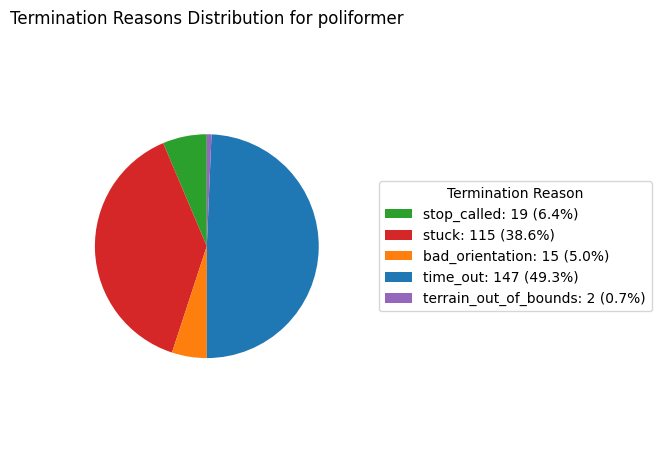

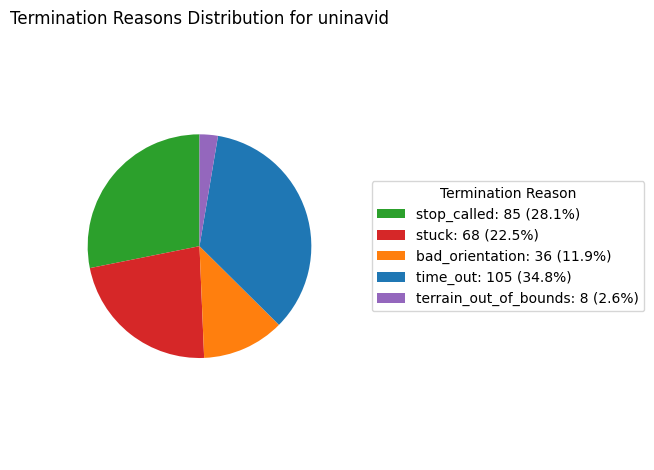

In [26]:
## --------- Pie Chart for Termination Reasons --------- ##
records_poliformer = load_records(poliformer_path, method_name="poliformer")
draw_pie_for_termination(records_poliformer, method_name="poliformer")

records_uninavid = load_records(uninavid_path, method_name="uninavid")
draw_pie_for_termination(records_uninavid, method_name="uninavid")

In [31]:
# Seperate Indoor and Outdoor
poliformer_grCommercial = [d for d in records_poliformer if d['episode_label'].startswith('grCommercial')]
poliformer_vc = [d for d in records_poliformer if d['episode_label'].startswith('vc')]

print("Poliformer grCommercial:", poliformer_grCommercial)
print("Poliformer vc:", poliformer_vc)

uninavid_grCommercial = [d for d in records_uninavid if d['episode_label'].startswith('grCommercial')]
uninavid_vc = [d for d in records_uninavid if d['episode_label'].startswith('vc')]

print("Uninavid grCommercial:", uninavid_grCommercial)
print("Uninavid vc:", uninavid_vc)

Poliformer grCommercial: [{'step': 5, 'episode_label': 'grCommercial_scene8_14', 'scene_id': 'grCommercial_scene8', 'episode_id': 14, 'instruction': 'telephone', 'path_length': 1.2409406918493695, 'distance_to_goal': 5.276139375071603, 'closest_goal': 0, 'success': 0.0, 'spl': 0.0, 'oracle_navigation_error': 5.1268106929050425, 'oracle_success': 0.0, 'sim_duration': 2.5, 'termination_reason': 'bad_orientation', 'episode_duration': 492.91339015960693, 'video_save_path': './dump/benchmark_poliformer_20260128_022849/vid/grCommercial_scene8_14_rgb_PoliFormer.mp4', 'method': 'poliformer'}, {'step': 57, 'episode_label': 'grCommercial_scene8_13', 'scene_id': 'grCommercial_scene8', 'episode_id': 13, 'instruction': 'couch', 'path_length': 13.760180671050284, 'distance_to_goal': 0.7525067229751812, 'closest_goal': 0, 'success': 0.0, 'spl': 0.0, 'oracle_navigation_error': 0.7525067229751812, 'oracle_success': 1.0, 'sim_duration': 39.650000000000006, 'termination_reason': 'stuck', 'episode_duratio